importing libraries 

In [175]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.experimental import enable_iterative_imputer  
from sklearn.linear_model import BayesianRidge
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn import metrics
import pyreadstat
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant as ac 
import random

load data

In [133]:
df, meta = pyreadstat.read_sav('data.sav')
df.head()

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,526301100.0,20.0,RL,141.0,31770.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,NA,0.0,5.0,2010.0,WD,Normal,215000.0
1,2.0,526350040.0,20.0,RH,80.0,11622.0,Pave,NA,Reg,Lvl,...,0.0,NA,MnPrv,NA,0.0,6.0,2010.0,WD,Normal,105000.0
2,3.0,526351010.0,20.0,RL,81.0,14267.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,Gar2,12500.0,6.0,2010.0,WD,Normal,172000.0
3,4.0,526353030.0,20.0,RL,93.0,11160.0,Pave,NA,Reg,Lvl,...,0.0,NA,NA,NA,0.0,4.0,2010.0,WD,Normal,244000.0
4,5.0,527105010.0,60.0,RL,74.0,13830.0,Pave,NA,IR1,Lvl,...,0.0,NA,MnPrv,NA,0.0,3.0,2010.0,WD,Normal,189900.0


Data Label

Distribution for LotFrontage: Linear feet of street connected to property after imputation 

In [134]:
for col, label in meta.column_names_to_labels.items():
    print(f"{col}: {label}")

Order: Observation number/ID.
PID: Parcel identification number (used for city web site review).
MSSubClass: Type of dwelling involved in the sale (a coded category).
MSZoning: General zoning classification of the sale.
LotFrontage: Linear feet of street connected to property.
LotArea: Lot size in square feet.
Street: Type of road access to property (e.g., Paved, Gravel).
Alley: Type of alley access to property.
LotShape: General shape of property (e.g., Regular, Irregular).
LandContour: Flatness of the property.
Utilities: Type of utilities available.
LotConfig: Lot configuration (e.g., Corner, Inside).
LandSlope: Slope of property (e.g., Gentle, Moderate, Severe).
Neighborhood: Physical locations within Ames city limits.
Condition1: Proximity to main road or railroad.
Condition2: Proximity to a second main road or railroad (if present).
BldgType: Type of dwelling (e.g., Single-family, Duplex).
HouseStyle: Style of dwelling (e.g., 1Story, 2Story, Split Level).
OverallQual: Overall mat

Null Count 

In [135]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

LotFrontage     490
MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt     159
GarageCars        1
GarageArea        1
dtype: int64


Variables' unique value

In [136]:
unique_values = {col:df[col].unique() 
                 for col in df.select_dtypes(include=['object', 'category']).columns}

for col, values in unique_values.items():
    print(f"Variable: {col}")
    print(f"Values:   {values}")
    print("-" * 30)

Variable: MSZoning
Values:   ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
------------------------------
Variable: Street
Values:   ['Pave' 'Grvl']
------------------------------
Variable: Alley
Values:   ['NA' 'Pave' 'Grvl']
------------------------------
Variable: LotShape
Values:   ['IR1' 'Reg' 'IR2' 'IR3']
------------------------------
Variable: LandContour
Values:   ['Lvl' 'HLS' 'Bnk' 'Low']
------------------------------
Variable: Utilities
Values:   ['AllPub' 'NoSewr' 'NoSeWa']
------------------------------
Variable: LotConfig
Values:   ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
------------------------------
Variable: LandSlope
Values:   ['Gtl' 'Mod' 'Sev']
------------------------------
Variable: Neighborhood
Values:   ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 

number of categorical and numeric data

In [137]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
print(f"Categorical columns detected: {len(cat_cols)}")
print(f"Numerical columns detected: {len(num_cols)}")

Categorical columns detected: 43
Numerical columns detected: 39


ENCODE CATEGORICAL DATA

In [138]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

df_encoded = df.copy()
if cat_cols:
    df_encoded[cat_cols] = encoder.fit_transform(df[cat_cols])

MICE IMPUTATION

In [139]:
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=10),
    max_iter=10,
    random_state=10,
    verbose=1
)

imputed_array = mice_imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df.columns)

[IterativeImputer] Completing matrix with shape (2930, 82)
[IterativeImputer] Change: 764.2917403597341, scaled tolerance: 1007100.11 
[IterativeImputer] Early stopping criterion reached.


rounding values 

In [140]:
if cat_cols:
    df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols].round().astype(int))

null count after the imputation 

In [141]:
null_counts = df_imputed.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


variance check

In [142]:
variances = df_encoded.var()
variance_df = pd.DataFrame(variances, columns=['Variance'])
variance_df = variance_df.sort_values(by='Variance', ascending=True)

print("--- Variables with the Lowest Variance ---")
print(variance_df.head(20))

threshold = 0.1
low_variance_cols = variance_df[variance_df['Variance'] < threshold].index.tolist()

print(f"\nColumns with variance below {threshold}:")
print(low_variance_cols)

--- Variables with the Lowest Variance ---
              Variance
Utilities     0.003070
Street        0.004080
PoolQC        0.017378
Condition2    0.043697
KitchenAbvGr  0.045829
Heating       0.060134
BsmtHalfBath  0.060149
LandSlope     0.061655
CentralAir    0.062441
Alley         0.067394
MiscFeature   0.133042
HalfBath      0.252636
BsmtFullBath  0.275436
PavedDrive    0.287713
RoofMatl      0.289671
FullBath      0.305743
Fireplaces    0.419802
ExterQual     0.492330
LandContour   0.494489
Foundation    0.527359

Columns with variance below 0.1:
['Utilities', 'Street', 'PoolQC', 'Condition2', 'KitchenAbvGr', 'Heating', 'BsmtHalfBath', 'LandSlope', 'CentralAir', 'Alley']


correlation check

In [143]:
vars_to_check = ['KitchenAbvGr', 'BsmtHalfBath', 'SalePrice']

specific_correlations = df_encoded[vars_to_check].corr()[['SalePrice']]

correlations_threshold = 0.1
low_corr_cols = specific_correlations[abs(specific_correlations['SalePrice']) < correlations_threshold]

print("Correlation with SalePrice:")
print(specific_correlations.drop('SalePrice'))
print(f"\nColumns with low correlation to SalePrice (Abs Corr < {correlations_threshold}):")
print(low_corr_cols)

Correlation with SalePrice:
              SalePrice
KitchenAbvGr  -0.119814
BsmtHalfBath  -0.035835

Columns with low correlation to SalePrice (Abs Corr < 0.1):
              SalePrice
BsmtHalfBath  -0.035835


In [144]:
X_cat = df_encoded[cat_cols].fillna(0).abs() 
y_binned = pd.qcut(df_encoded['SalePrice'], q=4, labels=False)

chi_scores, p_values = chi2(X_cat, y_binned)

chi2_df = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2_Score': chi_scores,
    'P_Value': p_values
})

chi2_df = chi2_df.sort_values(by='P_Value', ascending=False)

print("\n--- Categorical Variables with Weakest Relationship to SalePrice ---")
print("(P-Values > 0.05 suggest the variable is independent/irrelevant)")
print(chi2_df.head(10))

p_val_threshold = 0.05

low_association = chi2_df[chi2_df['P_Value'] > p_val_threshold]['Feature'].tolist()

print(f"\nColumns with low association (P-Value > {p_val_threshold}):")
print(low_association)




--- Categorical Variables with Weakest Relationship to SalePrice ---
(P-Values > 0.05 suggest the variable is independent/irrelevant)
         Feature  Chi2_Score   P_Value
1         Street    0.064834  0.995694
38        PoolQC    0.074421  0.994719
10    Condition2    0.085146  0.993558
40   MiscFeature    0.786564  0.852678
4    LandContour    2.174605  0.536968
26       Heating    2.479334  0.479038
25  BsmtFinType2    3.392834  0.334929
14      RoofMatl    5.015774  0.170646
41      SaleType    6.276327  0.098914
2          Alley    7.123694  0.068058

Columns with low association (P-Value > 0.05):
['Street', 'PoolQC', 'Condition2', 'MiscFeature', 'LandContour', 'Heating', 'BsmtFinType2', 'RoofMatl', 'SaleType', 'Alley']


In [145]:
cols_likely_to_drop = list((set(low_variance_cols) 
                            & set(low_association)) 
                           | set(low_corr_cols.index.tolist()))

print(cols_likely_to_drop)

['Street', 'BsmtHalfBath', 'Condition2', 'PoolQC', 'Alley', 'Heating']


VIF

In [146]:
X = df_imputed.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) 
                 for i in range(len(X_with_const.columns))]

vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Global VIF Results for numerical features:
          feature           VIF
17   LowQualFinSF           inf
18      GrLivArea           inf
15      @1stFlrSF           inf
16      @2ndFlrSF           inf
11     BsmtFinSF1  5.586814e+04
14    TotalBsmtSF  5.226081e+04
13      BsmtUnfSF  5.198893e+04
12     BsmtFinSF2  7.704249e+03
1           Order  7.930460e+01
38         YrSold  7.724025e+01
39      SalePrice  6.118867e+00
8       YearBuilt  5.864018e+00
29     GarageArea  5.839543e+00
28     GarageCars  5.828526e+00
27    GarageYrBlt  4.624231e+00
25   TotRmsAbvGrd  4.465149e+00
2             PID  3.776358e+00
6     OverallQual  3.773019e+00
21       FullBath  2.813025e+00
9    YearRemodAdd  2.450877e+00
23   BedroomAbvGr  2.395629e+00
22       HalfBath  2.179785e+00
19   BsmtFullBath  2.162602e+00
4     LotFrontage  1.857150e+00
3      MSSubClass  1.726864e+00
24   KitchenAbvGr  1.580021e+00
26     Fireplaces  1.568200e+00
7     OverallCond  1.543243e+00
10     MasVnrArea  1.476725e+

In [147]:
grliv_sum_array = df_imputed['@1stFlrSF'] + df_imputed['@2ndFlrSF'] + df_imputed['LowQualFinSF']
grliv_difference = df_imputed['GrLivArea'] - grliv_sum_array

bsmt_sum_array = df_imputed['BsmtFinSF1'] + df_imputed['BsmtFinSF2'] + df_imputed['BsmtUnfSF']
bsmt_difference = df_imputed['TotalBsmtSF'] - bsmt_sum_array

print(grliv_difference)
print(bsmt_difference)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64


As TotalBsmtSF is sum of BsmtFinSF1, BsmtFinSF2, BsmtUnfSF
and GrLivArea is sum of @1stFlrSF, @2ndFlrSF, LowQualFinSF.


we drop these two variable from the model 

In [148]:
cols_to_drop = [ 'Order', 'PID','GrLivArea', 'TotalBsmtSF'] + cols_likely_to_drop
df_reduced = df_imputed.drop(columns=cols_to_drop)

df_numeric_ready = pd.get_dummies(df_reduced, drop_first=True)

df_refined = df_numeric_ready.copy()

VIF After the dropping the variable

In [149]:
X = df_refined.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) for i in range(len(X_with_const.columns))]
vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature       VIF
12      @1stFlrSF  6.198723
13      @2ndFlrSF  6.158087
34      SalePrice  6.098010
24     GarageArea  5.829924
23     GarageCars  5.800241
6       YearBuilt  5.721309
9      BsmtFinSF1  5.020754
22    GarageYrBlt  4.623426
20   TotRmsAbvGrd  4.448893
4     OverallQual  3.750347
11      BsmtUnfSF  3.736066
16       FullBath  2.788994
7    YearRemodAdd  2.418515
18   BedroomAbvGr  2.371233
17       HalfBath  2.147400
15   BsmtFullBath  1.966123
2     LotFrontage  1.845730
1      MSSubClass  1.718068
19   KitchenAbvGr  1.572956
21     Fireplaces  1.565738
10     BsmtFinSF2  1.547719
5     OverallCond  1.530275
8      MasVnrArea  1.460977
3         LotArea  1.351295
27  EnclosedPorch  1.240633
25     WoodDeckSF  1.228720
26    OpenPorchSF  1.223763
29    ScreenPorch  1.092769
30       PoolArea  1.088408
14   LowQualFinSF  1.080585
31        MiscVal  1.074784
33         YrSold  1.046566
32         MoSold  1.040789
28   

Calculating the correlation matrix

In [150]:
corr_matrix = X.corr()
eigenvalues = np.linalg.eigvals(corr_matrix)

condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())

print(f"Condition Number (Kappa): {condition_number:.2f}")
if condition_number > 30:
    print("Severe multicollinearity detected (Condition Number > 30).")

Condition Number (Kappa): 9.80


split the data

In [151]:
y = df_refined['SalePrice'] 
X = df_refined.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Auto Correlation Check

Durbin-Watson statistic: 1.9733
Result: Little to no evidence of autocorrelation (values between 1.5 and 2.5 are ideal).


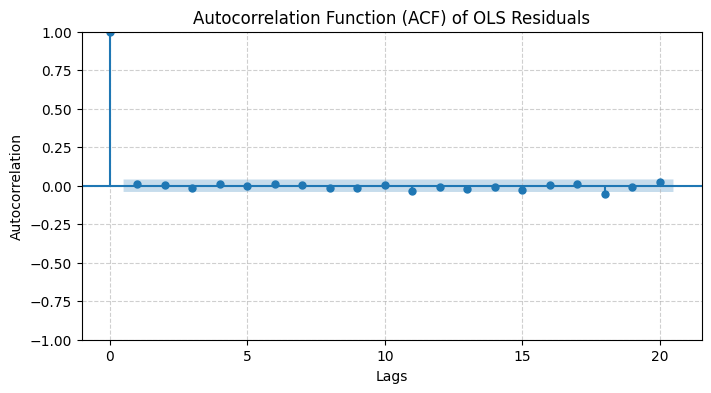

In [176]:
def analyze_and_fix_autocorrelation(X_train, y_train, max_iter=5, lag=1):

    X_train_sm = sm.add_constant(X_train)
    
    ols_model = sm.OLS(y_train, X_train_sm).fit()
    residuals = ols_model.resid
    
    dw_stat = durbin_watson(residuals)
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    if dw_stat < 1.5:
        print("Result: Strong evidence of POSITIVE autocorrelation.")
    elif dw_stat > 2.5:
        print("Result: Strong evidence of NEGATIVE autocorrelation.")
    else:
        print("Result: Little to no evidence of autocorrelation (values between 1.5 and 2.5 are ideal).")
        
    # Plot Autocorrelation Function (ACF)
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_acf(residuals, lags=20, ax=ax, alpha=0.05)
    plt.title("Autocorrelation Function (ACF) of OLS Residuals")
    plt.xlabel("Lags")
    plt.ylabel("Autocorrelation")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return ols_model

analyze_and_fix_autocorrelation(X_train_scaled, y_train)

Ridge Trace graph

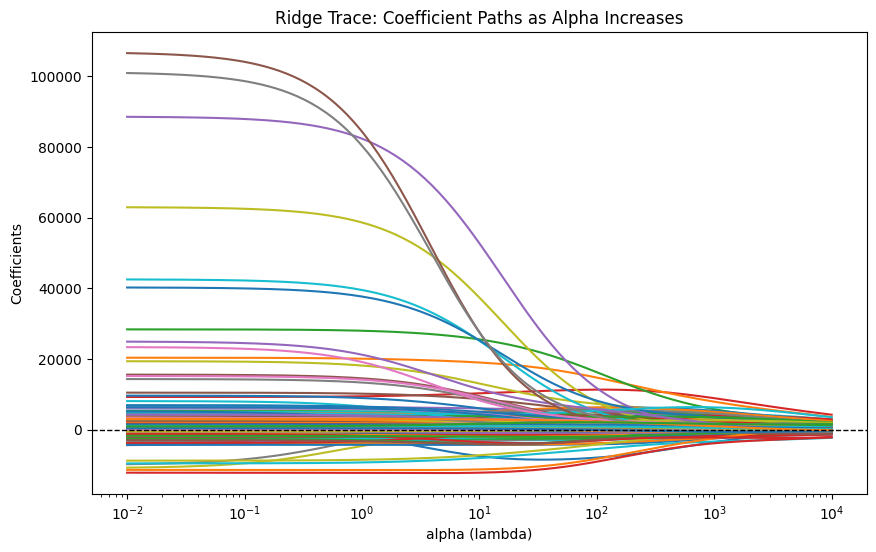

In [152]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

alphas = np.logspace(-2, 4, 200)
coefs = []

for a in alphas:
    ridge_trace = Ridge(alpha=a)
    ridge_trace.fit(X_train_scaled, y_train)
    coefs.append(ridge_trace.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.title('Ridge Trace: Coefficient Paths as Alpha Increases')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axis('tight')
plt.show()

In [153]:
ridge = Ridge(alpha=0.6)
ridge.fit(X_train_scaled, y_train)

Ridge(alpha=0.6)

In [154]:
alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

optimal_lambda = lasso_cv.alpha_
print(f"The optimal lambda is: {optimal_lambda}")

lasso = Lasso(alpha=optimal_lambda, max_iter=10000)
lasso.fit(X_train_scaled, y_train)


C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 85036788618.09149, tolerance: 1132319147.6520545
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1842242628.291504, tolerance: 1132319147.6520545
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWar

The optimal lambda is: 10.0


Lasso(alpha=np.float64(10.0), max_iter=10000)

In [155]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net.fit(X_train_scaled, y_train)

C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12599505103.949097, tolerance: 1132319147.6520545
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 41600430709.78473, tolerance: 1132319147.6520545
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWa

Optimal Alpha: 8.902150854450392
Optimal L1 Ratio: 0.99


ElasticNet(alpha=np.float64(8.902150854450392), l1_ratio=np.float64(0.99))

In [156]:
pcr = make_pipeline(PCA(n_components=0.95), LinearRegression())
pcr.fit(X_train_scaled, y_train)

Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('linearregression', LinearRegression())])

In [157]:
def evaluate(model, name):
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, preds))
    r2 = metrics.r2_score(y_test, preds)
    print(f"{name:20s} | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

print("--- Model Performance Comparison ---")
evaluate(ols, "Standard OLS")
evaluate(ridge, "Ridge Regression")
evaluate(lasso, "LASSO Regression")
evaluate(elastic_net, "Elastic Net")
evaluate(pcr, "PCR (95% variance)")

--- Model Performance Comparison ---
Standard OLS         | RMSE: $35,408.97 | R2: 0.8436
Ridge Regression     | RMSE: $33,755.56 | R2: 0.8579
LASSO Regression     | RMSE: $34,475.46 | R2: 0.8518
Elastic Net          | RMSE: $29,330.97 | R2: 0.8927
PCR (95% variance)   | RMSE: $31,467.66 | R2: 0.8765


extracting the specific features that elastic net deemed most important

In [158]:
en_coefs = elastic_net.coef_

# 3. Create the DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': en_coefs
})

# 4. Filter for features that are NOT zero
non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

# 5. Sort by absolute importance
non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 263
Features kept by Elastic Net (non-zero): 254

--- Top 20 Most Important Features ---
             Feature  Coefficient
           @1stFlrSF 12435.082409
           @2ndFlrSF 12058.872737
         OverallQual 11184.191399
      KitchenQual_TA -7058.890797
             MiscVal -6877.904188
          BsmtFinSF1  6360.558974
      KitchenQual_Gd -6291.644241
Neighborhood_NoRidge  6275.924185
Neighborhood_NridgHt  6207.848171
         BsmtQual_Ex  5932.198134
    RoofMatl_WdShngl  5756.332258
    RoofMatl_CompShg  5692.890236
Neighborhood_StoneBr  5429.754683
          GarageCars  4946.823173
            FullBath  4709.253686
         OverallCond  4699.600158
        ExterQual_TA -4560.895993
    MiscFeature_Gar2  4499.188547
             LotArea  3937.230249
          MSSubClass -3865.540418


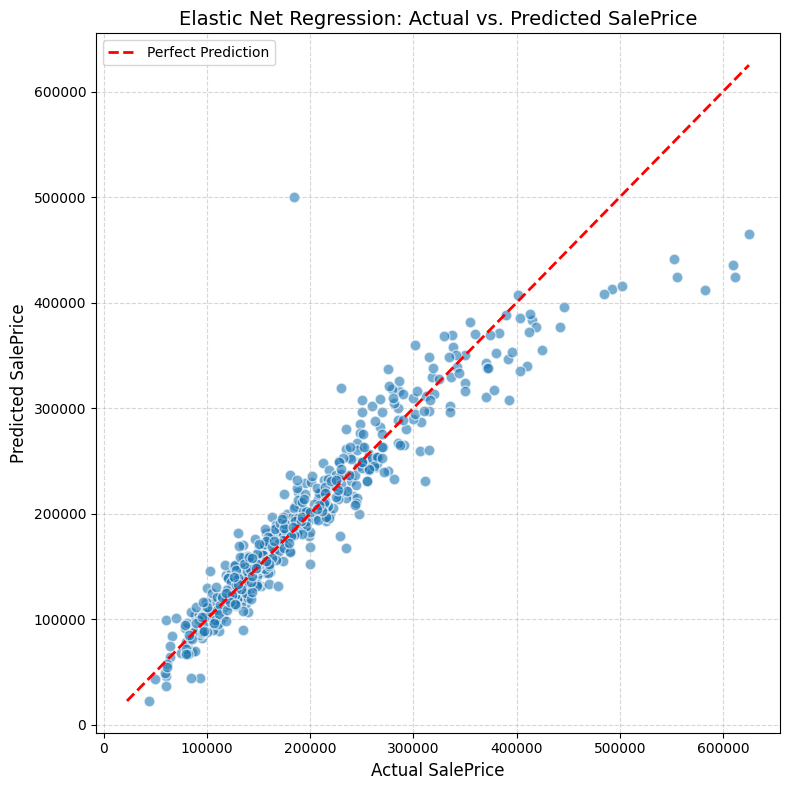

In [159]:
elastic_net_pred = elastic_net.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, elastic_net_pred, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test.min(), elastic_net_pred.min())
max_val = max(y_test.max(), elastic_net_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

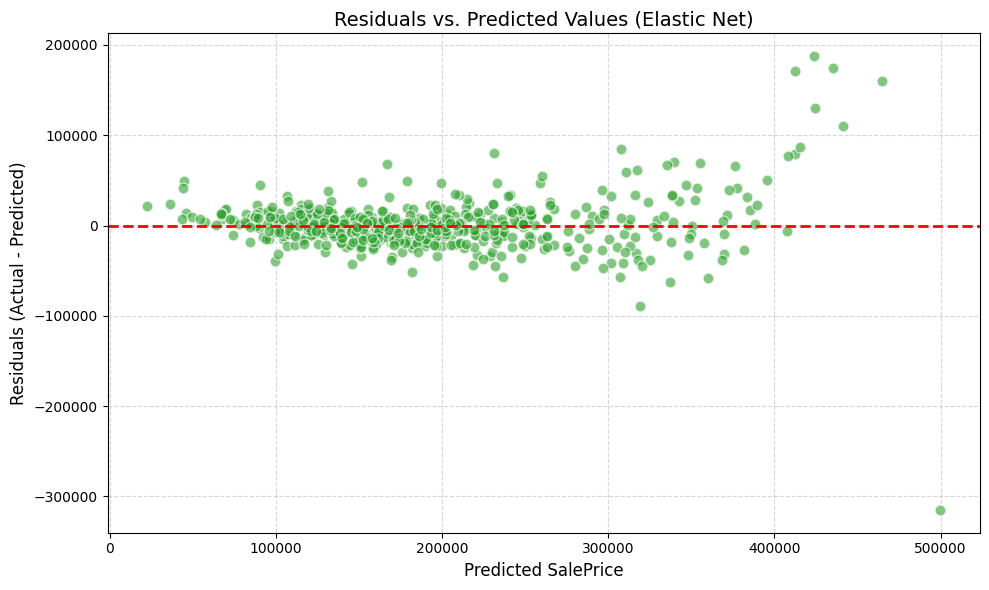

In [160]:
residuals = y_test - elastic_net_pred

plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred, residuals, alpha=0.6, color='#2ca02c', edgecolors='w', s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

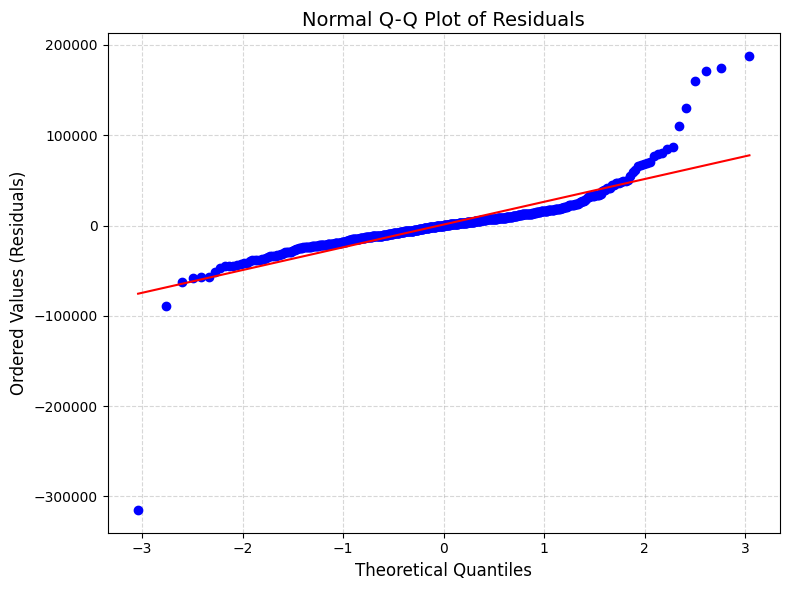

In [161]:
residuals = y_test - elastic_net_pred

plt.figure(figsize=(8, 6))

# 2. Generate the Q-Q plot
# 'dist="norm"' compares your residuals against a normal distribution
stats.probplot(residuals, dist="norm", plot=plt)

# 3. Customizing the plot
plt.title('Normal Q-Q Plot of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [162]:
y_train_bc, lam = boxcox(y_train)
y_test_bc = boxcox(y_test, lmbda=lam)
print(f"Optimal Box-Cox Lambda: {lam:.4f}")
pt = PowerTransformer(method='yeo-johnson')

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)


Optimal Box-Cox Lambda: 0.0443


C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


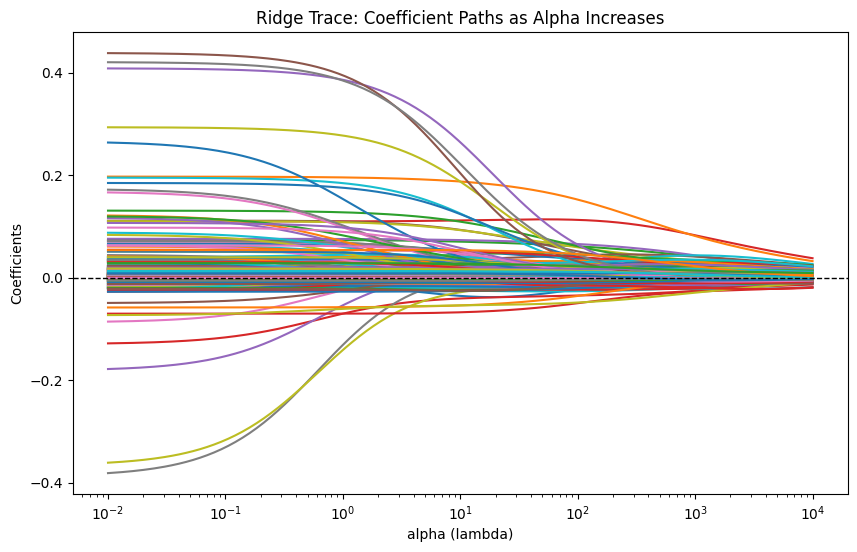

In [163]:
ols = LinearRegression()
ols.fit(X_train_transformed, y_train_bc)

alphas = np.logspace(-2, 4, 200)
coefs = []

for a in alphas:
    ridge_trace = Ridge(alpha=a)
    ridge_trace.fit(X_train_transformed, y_train_bc)
    coefs.append(ridge_trace.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.title('Ridge Trace: Coefficient Paths as Alpha Increases')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axis('tight')
plt.show()

In [164]:
ridge = Ridge(alpha=0.5)
ridge.fit(X_train_transformed, y_train_bc)

Ridge(alpha=0.5)

In [165]:
alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_transformed, y_train_bc)

optimal_lambda = lasso_cv.alpha_
print(f"The optimal lambda is: {optimal_lambda}")

lasso = Lasso(alpha=optimal_lambda, max_iter=10000)
lasso.fit(X_train_transformed, y_train_bc)


C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1215767353216819, tolerance: 0.08628678720582832
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1525185458005751, tolerance: 0.08628678720582832
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: Convergenc

The optimal lambda is: 0.0036783797718286343


Lasso(alpha=np.float64(0.0036783797718286343), max_iter=10000)

In [166]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_transformed, y_train_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net.fit(X_train_transformed, y_train_bc)

C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.21280715215249302, tolerance: 0.08806138124587452
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2721772218227514, tolerance: 0.08806138124587452
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: Convergen

Optimal Alpha: 0.0036783797718286343
Optimal L1 Ratio: 1.0


C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.09001191861923985, tolerance: 0.08861322519965863
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1063602396997112, tolerance: 0.08861322519965863
  model = cd_fast.enet_coordinate_descent_gram(


ElasticNet(alpha=np.float64(0.0036783797718286343), l1_ratio=np.float64(1.0))

In [167]:
pcr = make_pipeline(PCA(n_components=0.95), LinearRegression())
pcr.fit(X_train_transformed, y_train_bc)

Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('linearregression', LinearRegression())])

In [168]:
def evaluate(model, name):
    preds = model.predict(X_test_transformed)
    rmse = np.sqrt(metrics.mean_squared_error(y_test_bc, preds))
    r2 = metrics.r2_score(y_test_bc, preds)
    print(f"{name:20s} | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

print("--- Model Performance Comparison ---")
evaluate(ols, "Standard OLS")
evaluate(ridge, "Ridge Regression")
evaluate(lasso, "LASSO Regression")
evaluate(elastic_net, "Elastic Net")
evaluate(pcr, "PCR (95% variance)")

--- Model Performance Comparison ---
Standard OLS         | RMSE: $0.25 | R2: 0.8884
Ridge Regression     | RMSE: $0.24 | R2: 0.8976
LASSO Regression     | RMSE: $0.20 | R2: 0.9239
Elastic Net          | RMSE: $0.20 | R2: 0.9239
PCR (95% variance)   | RMSE: $0.22 | R2: 0.9118


In [169]:
en_coefs = elastic_net.coef_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': en_coefs
})

non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 263
Features kept by Elastic Net (non-zero): 141

--- Top 20 Most Important Features ---
             Feature  Coefficient
           @1stFlrSF     0.177819
         OverallQual     0.143695
           @2ndFlrSF     0.095979
           YearBuilt     0.079945
         OverallCond     0.071461
             LotArea     0.064395
          GarageCars     0.055131
          BsmtFinSF1     0.052077
      Functional_Sal    -0.048265
            FullBath     0.036789
SaleCondition_Normal     0.034466
Neighborhood_NridgHt     0.033268
         BsmtQual_Ex     0.032855
Neighborhood_Crawfor     0.031765
          Fireplaces     0.031672
Neighborhood_NoRidge     0.029025
     BsmtExposure_Gd     0.028450
    MSZoning_C (all)    -0.028281
     Condition1_Norm     0.025286
 Exterior1st_BrkFace     0.024830


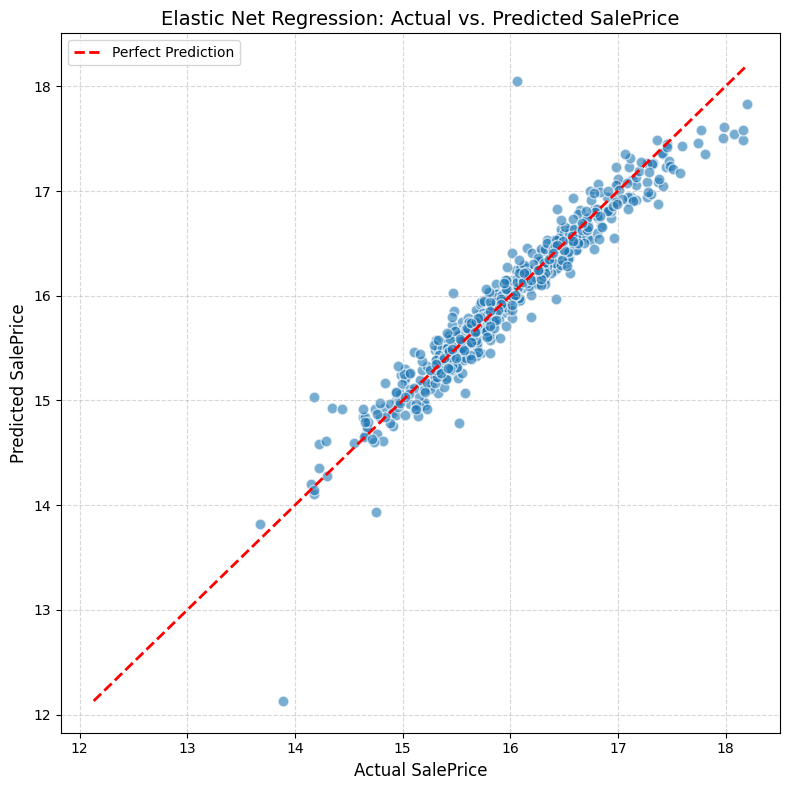

In [170]:
elastic_net_pred_transform = elastic_net.predict(X_test_transformed)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_bc, elastic_net_pred_transform, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test_bc.min(), elastic_net_pred_transform.min())
max_val = max(y_test_bc.max(), elastic_net_pred_transform.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

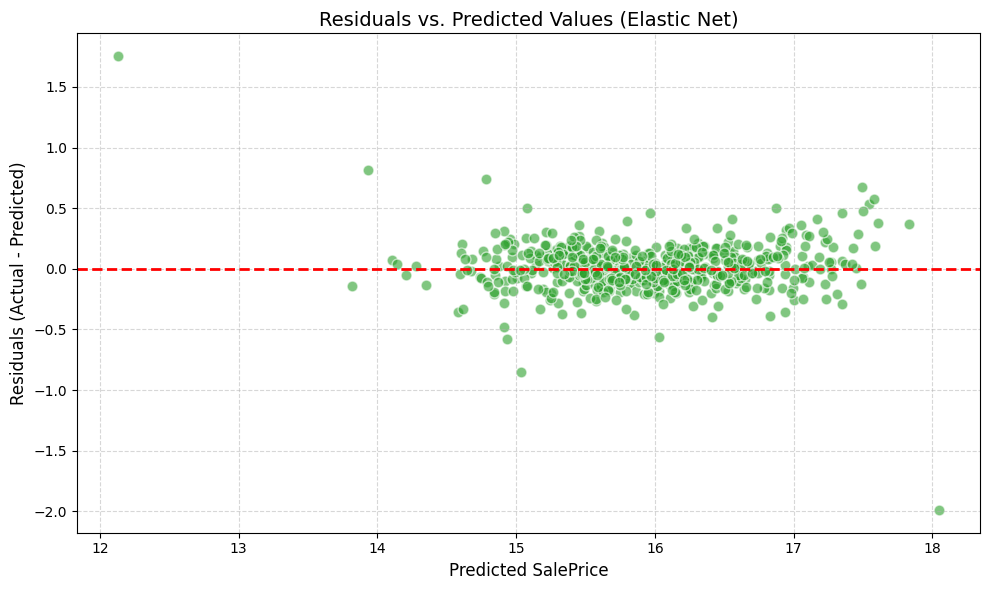

In [171]:
residuals = y_test_bc - elastic_net_pred_transform

plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred_transform, residuals, 
            alpha=0.6, 
            color='#2ca02c', 
            edgecolors='w', 
            s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

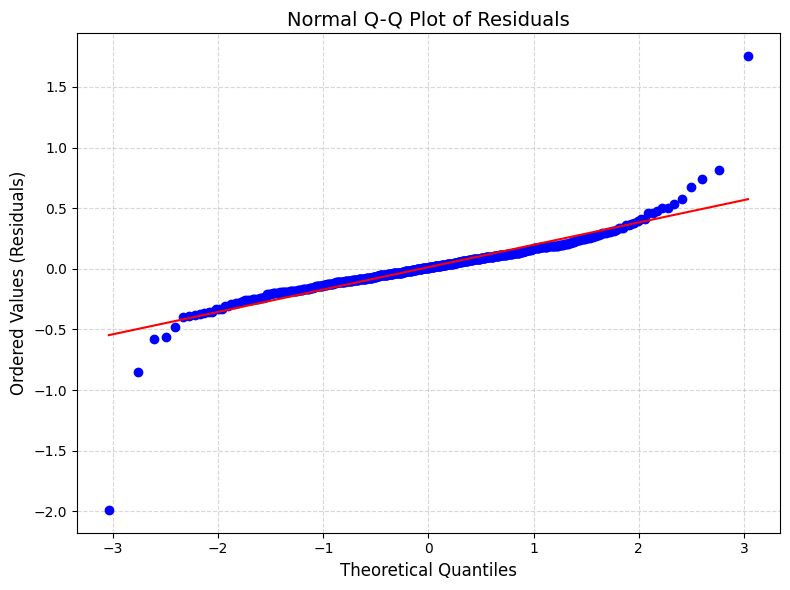

In [172]:
residuals = y_test_bc - elastic_net_pred_transform

plt.figure(figsize=(8, 6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title('Normal Q-Q Plot of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: divide by zero encountered in divide
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\mkabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:867: RuntimeWarning: divide by zero encountered in divide
  cooks_d2 *= hii / (1 - hii)


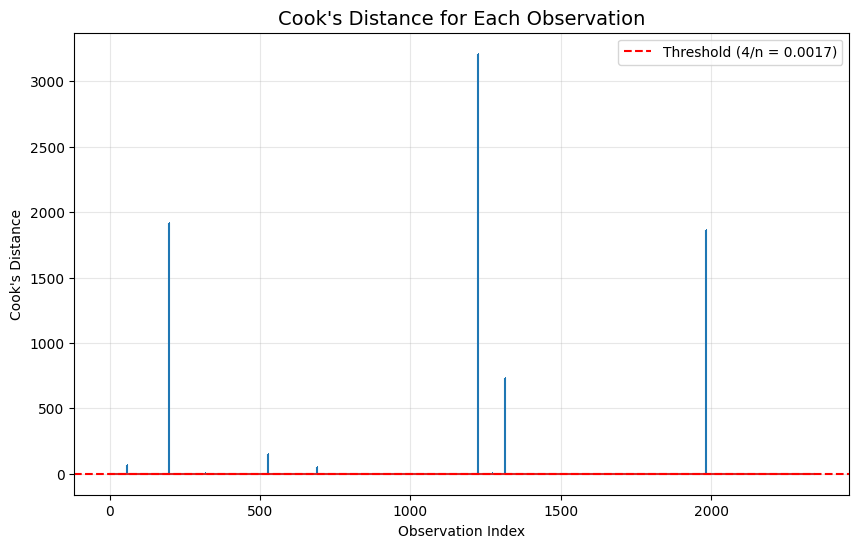

In [173]:
X_with_constant = sm.add_constant(X_train_transformed)

model = sm.OLS(y_train_bc, X_with_constant)
results_enet = model.fit_regularized(method='elastic_net', 
                                     alpha=en_cv.alpha_, 
                                     L1_wt=en_cv.l1_ratio_)

influence = sm.OLS(y_train_bc, X_with_constant).fit().get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")

threshold = 4 / len(c)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.title("Cook's Distance for Each Observation", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()